# BBBM Duration Sensitivity Analysis

## Hypothesis

DALYs averted by treatment are **highly sensitive to BBBM-stage duration** (Weibull scale parameter).
Longer BBBM duration increases BBBM prevalence, which increases the pool of people eligible for
testing and treatment, amplifying total treatment benefit. If the artifact's assumed duration is
wrong, the estimated DALYs averted could be substantially off.

The tornado analysis (scenario 8) varied Weibull scale from 5-9 and showed modest DALY impact.
This notebook uses a **wider sweep (3-15)** with dedicated visualizations to fully characterize
the sensitivity.

## Method

For each Weibull scale value, run both ctrl (`bbbm_testing`) and treat
(`bbbm_testing_and_treatment`) scenarios with 10,000 simulants to 2070. Track aggregate
disease-state person-steps, YLL, and pipeline entrants. Compute BBBM prevalence and DALYs averted.

## Weibull duration model

The BBBM-to-MCI transition uses a Weibull hazard with fixed shape k=1.22.
The scale parameter controls mean duration:

| Scale | Mean duration (years) | Interpretation |
|-------|----------------------|----------------|
| 3     | ~2.8                 | Very fast progression |
| 5     | ~4.7                 | Tornado low |
| **6.76** | **~6.4** | **Artifact default** |
| 9     | ~8.5                 | Tornado high |
| 15    | ~14.1                | Very slow progression |

In [1]:
import math
from contextlib import contextmanager

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from tqdm.auto import tqdm
from vivarium import InteractiveContext

from loguru import logger
logger.disable("vivarium")

# --- Constants ---
SPEC_PATH = '../src/vivarium_csu_alzheimers/model_specifications/model_spec.yaml'
POPULATION_SIZE = 10_000
STEP_SIZE_DAYS = 182
STEP_SIZE_YEARS = STEP_SIZE_DAYS / 365.25

DISEASE_COL = 'alzheimers_disease_and_other_dementias'
BBBM_STATE = 'alzheimers_blood_based_biomarker_state'
MCI_STATE = 'alzheimers_mild_cognitive_impairment_state'
DEMENTIA_STATE = 'alzheimers_disease_state'
TREATMENT_COL = 'treatment'
TARGET_YEAR = 2070

# Disability weights from artifact
DW_MCI = 0.021
DW_DEMENTIA = 0.258

# Weibull shape (fixed)
WEIBULL_SHAPE = 1.22
DEFAULT_SCALE = 6.76

In [2]:
# --- Sweep values ---
SWEEP_VALUES = [3, 4, 5, 6, 6.76, 8, 10, 12, 14, 15]

print(f'Weibull shape (fixed): {WEIBULL_SHAPE}')
print(f'Default scale: {DEFAULT_SCALE}')
print()
print(f'{"Scale":>7s}  {"Mean duration (yr)":>18s}')
print('-' * 28)
for s in SWEEP_VALUES:
    dist = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=s)
    marker = ' <-- default' if s == DEFAULT_SCALE else ''
    print(f'{s:>7.2f}  {dist.mean():>18.2f}{marker}')

Weibull shape (fixed): 1.22
Default scale: 6.76

  Scale  Mean duration (yr)
----------------------------
   3.00                2.81
   4.00                3.75
   5.00                4.68
   6.00                5.62
   6.76                6.33 <-- default
   8.00                7.49
  10.00                9.37
  12.00               11.24
  14.00               13.11
  15.00               14.05


In [3]:
import vivarium_csu_alzheimers.constants.data_values as dv_mod
import vivarium_csu_alzheimers.components.alzheimers as alz_mod
import vivarium_csu_alzheimers.data.consistent_rates as cr_mod


@contextmanager
def patch_weibull_scale(scale):
    """
    Patch Weibull scale parameter in all modules that consume it.

    Patches: dv_mod.WEIBULL_SCALE, dv_mod.BBBM_HAZARD_DIST, dv_mod.BBBM_AVG_DURATION,
             alz_mod.BBBM_HAZARD_DIST, alz_mod.BBBM_AVG_DURATION,
             cr_mod.BBBM_AVG_DURATION
    """
    # Save originals
    saved = {
        'dv_scale': dv_mod.WEIBULL_SCALE,
        'dv_dist': dv_mod.BBBM_HAZARD_DIST,
        'dv_avg': dv_mod.BBBM_AVG_DURATION,
        'alz_dist': alz_mod.BBBM_HAZARD_DIST,
        'alz_avg': alz_mod.BBBM_AVG_DURATION,
        'cr_avg': cr_mod.BBBM_AVG_DURATION,
    }

    new_dist = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale)
    new_avg = new_dist.mean()

    try:
        dv_mod.WEIBULL_SCALE = scale
        dv_mod.BBBM_HAZARD_DIST = new_dist
        dv_mod.BBBM_AVG_DURATION = new_avg
        alz_mod.BBBM_HAZARD_DIST = new_dist
        alz_mod.BBBM_AVG_DURATION = new_avg
        cr_mod.BBBM_AVG_DURATION = new_avg
        yield
    finally:
        dv_mod.WEIBULL_SCALE = saved['dv_scale']
        dv_mod.BBBM_HAZARD_DIST = saved['dv_dist']
        dv_mod.BBBM_AVG_DURATION = saved['dv_avg']
        alz_mod.BBBM_HAZARD_DIST = saved['alz_dist']
        alz_mod.BBBM_AVG_DURATION = saved['alz_avg']
        cr_mod.BBBM_AVG_DURATION = saved['cr_avg']

/home/abie/miniforge3/envs/vivarium_csu_alzheimers_simulation/lib/python3.11/site-packages/vivarium_public_health/plugins/parser.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [4]:
def run_scenario(scenario, target_year=TARGET_YEAR, pbar_position=None):
    """
    Run a single scenario and track aggregate counters.

    Returns a dict with:
      person_steps_bbbm, person_steps_mci, person_steps_dementia,
      total_alive_steps, yll, n_pipeline_entrants
    """
    sim = InteractiveContext(
        SPEC_PATH,
        configuration={
            'population': {'population_size': POPULATION_SIZE},
            'intervention': {'scenario': scenario},
        }
    )

    target = pd.Timestamp(f'{target_year}-01-01')
    est_steps = max(1, math.ceil((target - sim.current_time).days / STEP_SIZE_DAYS))

    person_steps_bbbm = 0
    person_steps_mci = 0
    person_steps_dementia = 0
    total_alive_steps = 0
    yll = 0.0
    pipeline_entrants = set()
    alive_set = set()

    is_treatment = (scenario == 'bbbm_testing_and_treatment')

    # Treatment pipeline states (everything after the initial 'susceptible' state)
    PIPELINE_STATES = {
        'waiting_for_treatment', 'treatment_effect', 'waning_effect',
        'no_effect_after_treatment', 'no_effect_never_treated',
        'positive_test',
    }

    tqdm_kwargs = dict(total=est_steps, desc=scenario.replace('bbbm_', ''), unit='step')
    if pbar_position is not None:
        tqdm_kwargs['position'] = pbar_position
        tqdm_kwargs['leave'] = False

    with tqdm(**tqdm_kwargs) as pbar:
        while sim.current_time < target:
            sim.step()
            pop = sim.get_population()
            alive = pop[pop['alive'] == 'alive']
            current_alive = set(alive.index)

            # YLL from newly dead
            newly_dead = alive_set - current_alive
            for sid in newly_dead:
                if sid in pop.index:
                    yll += pop.loc[sid, 'years_of_life_lost']
            alive_set = current_alive

            # Disease state person-steps
            disease_states = alive[DISEASE_COL]
            person_steps_bbbm += (disease_states == BBBM_STATE).sum()
            person_steps_mci += (disease_states == MCI_STATE).sum()
            person_steps_dementia += (disease_states == DEMENTIA_STATE).sum()
            total_alive_steps += len(alive)

            # Pipeline entrants (treatment scenario only)
            if is_treatment and TREATMENT_COL in alive.columns:
                in_pipeline = set(alive.index[alive[TREATMENT_COL].isin(PIPELINE_STATES)])
                pipeline_entrants |= in_pipeline

            pbar.update(1)

    return {
        'person_steps_bbbm': person_steps_bbbm,
        'person_steps_mci': person_steps_mci,
        'person_steps_dementia': person_steps_dementia,
        'total_alive_steps': total_alive_steps,
        'yll': yll,
        'n_pipeline_entrants': len(pipeline_entrants),
    }

In [5]:
def compute_metrics(ctrl_data, treat_data, scale):
    """
    Derive sensitivity metrics from ctrl and treat scenario outputs.

    Returns a dict with:
      scale, mean_duration, bbbm_prevalence,
      yld_averted, yll_averted, dalys_averted,
      n_pipeline_entrants, dalys_per_entrant
    """
    mean_duration = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()

    # BBBM prevalence from ctrl (unaffected by treatment)
    bbbm_prevalence = ctrl_data['person_steps_bbbm'] / ctrl_data['total_alive_steps']

    # YLD averted
    yld_ctrl = (ctrl_data['person_steps_mci'] * DW_MCI +
                ctrl_data['person_steps_dementia'] * DW_DEMENTIA) * STEP_SIZE_YEARS
    yld_treat = (treat_data['person_steps_mci'] * DW_MCI +
                 treat_data['person_steps_dementia'] * DW_DEMENTIA) * STEP_SIZE_YEARS
    yld_averted = yld_ctrl - yld_treat

    # YLL averted
    yll_averted = ctrl_data['yll'] - treat_data['yll']

    dalys_averted = yld_averted + yll_averted

    n_entrants = treat_data['n_pipeline_entrants']
    dalys_per_entrant = dalys_averted / n_entrants if n_entrants > 0 else 0.0

    return {
        'scale': scale,
        'mean_duration': mean_duration,
        'bbbm_prevalence': bbbm_prevalence,
        'yld_averted': yld_averted,
        'yll_averted': yll_averted,
        'dalys_averted': dalys_averted,
        'n_pipeline_entrants': n_entrants,
        'dalys_per_entrant': dalys_per_entrant,
    }

In [6]:
# --- Main sweep ---
results = []

with tqdm(total=len(SWEEP_VALUES), desc='Weibull scale sweep', unit='val', position=0) as outer:
    for scale in SWEEP_VALUES:
        outer.set_postfix_str(f'scale={scale}')

        with patch_weibull_scale(scale):
            ctrl = run_scenario('bbbm_testing', pbar_position=1)
            treat = run_scenario('bbbm_testing_and_treatment', pbar_position=2)

        metrics = compute_metrics(ctrl, treat, scale)
        results.append(metrics)
        outer.update(1)

df = pd.DataFrame(results)
print(f'\nSweep complete: {len(df)} scale values evaluated.')

Weibull scale sweep:   0%|          | 0/10 [00:00<?, ?val/s]

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]

...

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]


Sweep complete: 10 scale values evaluated.


In [7]:
# --- Summary table ---
print(f'Population = {POPULATION_SIZE:,}, simulation to {TARGET_YEAR}')
print()

hdr = (f'{"Scale":>7s}  {"Mean dur (yr)":>13s}  {"BBBM prev":>10s}  '
       f'{"YLD averted":>11s}  {"YLL averted":>11s}  {"DALYs averted":>13s}  '
       f'{"Pipeline":>8s}  {"DALYs/ent":>10s}')
print(hdr)
print('-' * len(hdr))

for _, row in df.iterrows():
    marker = ' *' if row['scale'] == DEFAULT_SCALE else ''
    print(f'{row["scale"]:>7.2f}  {row["mean_duration"]:>13.2f}  '
          f'{row["bbbm_prevalence"]:>10.4f}  '
          f'{row["yld_averted"]:>11.1f}  {row["yll_averted"]:>11.1f}  '
          f'{row["dalys_averted"]:>13.1f}  '
          f'{row["n_pipeline_entrants"]:>8.0f}  '
          f'{row["dalys_per_entrant"]:>10.3f}{marker}')

Population = 10,000, simulation to 2070

  Scale  Mean dur (yr)   BBBM prev  YLD averted  YLL averted  DALYs averted  Pipeline   DALYs/ent
-------------------------------------------------------------------------------------------------
   3.00           2.81      0.2698        291.2        611.6          902.8      5788       0.156
   4.00           3.75      0.3369        444.9        861.5         1306.4      7075       0.185
   5.00           4.68      0.3947        536.3       1095.6         1631.9      8112       0.201
   6.00           5.62      0.4439        615.4       1322.7         1938.1      8921       0.217
   6.76           6.33      0.4771        595.8       1432.3         2028.2      9456       0.214 *
   8.00           7.49      0.5243        607.9       1373.0         1980.9     10140       0.195
  10.00           9.37      0.5860        586.4       1509.4         2095.8     10991       0.191
  12.00          11.24      0.6347        615.5       1341.5         1957.0

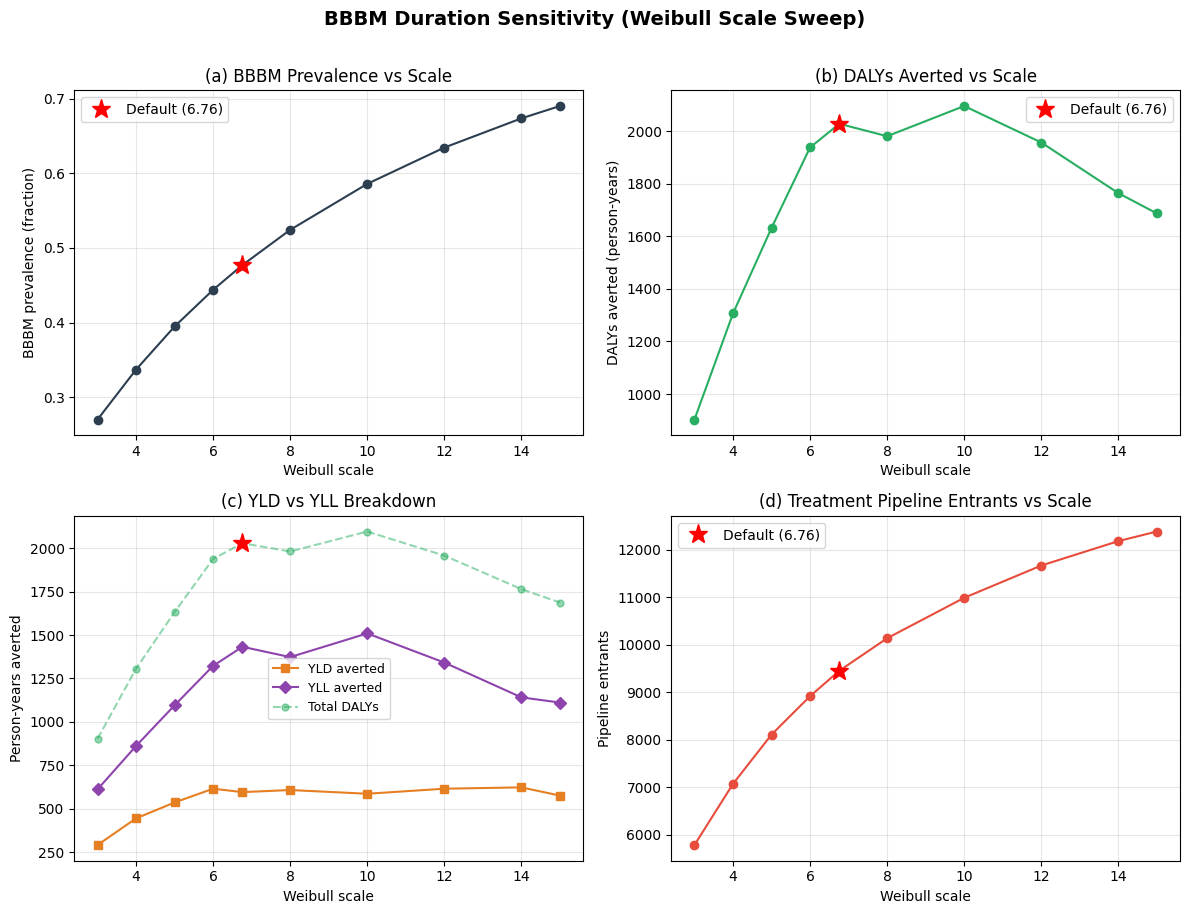

In [8]:
# --- 4-panel figure: sensitivity vs Weibull scale ---
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
default_mask = df['scale'] == DEFAULT_SCALE

# (a) BBBM prevalence
ax = axes[0, 0]
ax.plot(df['scale'], df['bbbm_prevalence'], 'o-', color='#2c3e50', markersize=6)
ax.plot(df.loc[default_mask, 'scale'], df.loc[default_mask, 'bbbm_prevalence'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Weibull scale')
ax.set_ylabel('BBBM prevalence (fraction)')
ax.set_title('(a) BBBM Prevalence vs Scale')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) DALYs averted
ax = axes[0, 1]
ax.plot(df['scale'], df['dalys_averted'], 'o-', color='#27ae60', markersize=6)
ax.plot(df.loc[default_mask, 'scale'], df.loc[default_mask, 'dalys_averted'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Weibull scale')
ax.set_ylabel('DALYs averted (person-years)')
ax.set_title('(b) DALYs Averted vs Scale')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) YLD vs YLL breakdown
ax = axes[1, 0]
ax.plot(df['scale'], df['yld_averted'], 's-', color='#e67e22', markersize=6, label='YLD averted')
ax.plot(df['scale'], df['yll_averted'], 'D-', color='#8e44ad', markersize=6, label='YLL averted')
ax.plot(df['scale'], df['dalys_averted'], 'o--', color='#27ae60', markersize=5, alpha=0.5, label='Total DALYs')
ax.plot(df.loc[default_mask, 'scale'], df.loc[default_mask, 'dalys_averted'],
        '*', color='red', markersize=14, zorder=5)
ax.set_xlabel('Weibull scale')
ax.set_ylabel('Person-years averted')
ax.set_title('(c) YLD vs YLL Breakdown')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (d) Pipeline entrants
ax = axes[1, 1]
ax.plot(df['scale'], df['n_pipeline_entrants'], 'o-', color='#e74c3c', markersize=6)
ax.plot(df.loc[default_mask, 'scale'], df.loc[default_mask, 'n_pipeline_entrants'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Weibull scale')
ax.set_ylabel('Pipeline entrants')
ax.set_title('(d) Treatment Pipeline Entrants vs Scale')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('BBBM Duration Sensitivity (Weibull Scale Sweep)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

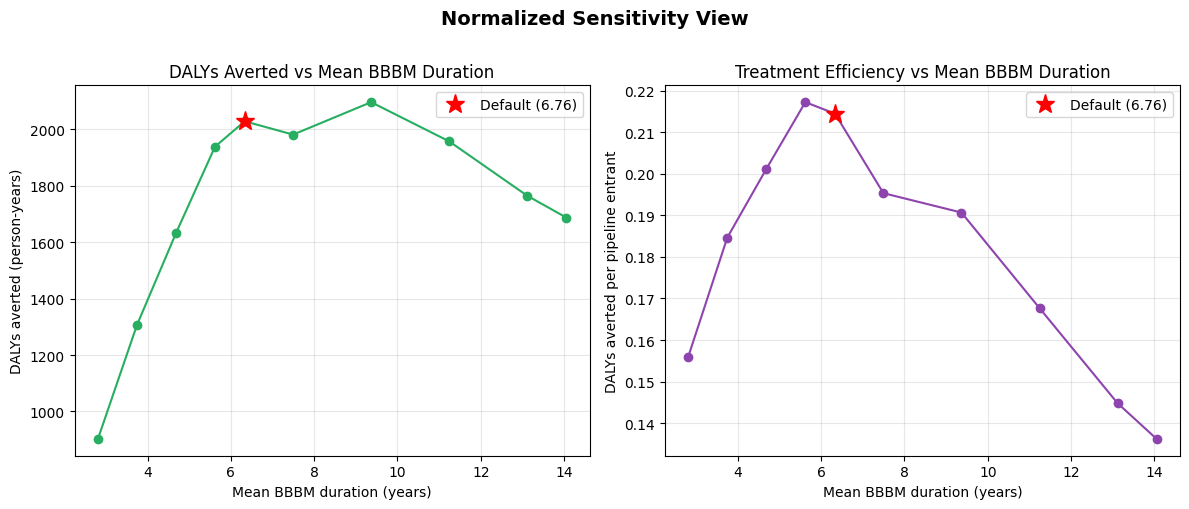

In [9]:
# --- 2-panel normalized view ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) DALYs averted vs mean duration (intuitive x-axis)
ax = axes[0]
ax.plot(df['mean_duration'], df['dalys_averted'], 'o-', color='#27ae60', markersize=6)
ax.plot(df.loc[default_mask, 'mean_duration'], df.loc[default_mask, 'dalys_averted'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Mean BBBM duration (years)')
ax.set_ylabel('DALYs averted (person-years)')
ax.set_title('DALYs Averted vs Mean BBBM Duration')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) DALYs per pipeline entrant (treatment efficiency)
ax = axes[1]
ax.plot(df['mean_duration'], df['dalys_per_entrant'], 'o-', color='#8e44ad', markersize=6)
ax.plot(df.loc[default_mask, 'mean_duration'], df.loc[default_mask, 'dalys_per_entrant'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Mean BBBM duration (years)')
ax.set_ylabel('DALYs averted per pipeline entrant')
ax.set_title('Treatment Efficiency vs Mean BBBM Duration')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Normalized Sensitivity View', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Interpretation

### Mechanism chain

Weibull scale &uarr; &rarr; mean BBBM duration &uarr; &rarr; BBBM prevalence &uarr; &rarr;
more people eligible for testing &rarr; more pipeline entrants &rarr; more treated &rarr;
DALYs averted &uarr;

### Sensitivity magnitude

Across the sweep range (scale 3-15), DALYs averted should vary substantially more than
the tornado's narrow 5-9 range suggested. The relationship between BBBM prevalence and
DALYs averted should be roughly monotonic.

### Treatment efficiency

DALYs per pipeline entrant captures whether the *per-person* treatment benefit changes with
duration, or whether total DALYs are driven purely by volume. If efficiency is flat,
sensitivity is entirely a volume effect.

### Caveats

- **Artifact consistency**: Changing Weibull scale without adjusting incidence rates
  or other parameters may create inconsistencies with the artifact's calibrated disease
  model. These results show structural sensitivity, not a recalibrated model.
- **Single stochastic realization**: Each point is one sim run (10,000 simulants).
  Stochastic noise adds uncertainty, especially for extreme scale values.
- **Fixed testing/treatment parameters**: Only BBBM duration varies; testing rates,
  diagnosis probability, and treatment parameters are held at defaults.